In [1]:
%env NX_CUGRAPH_AUTOCONFIG=True
import networkx as nx
import sys
from pathlib import Path
from tqdm.auto import tqdm 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import data_analysis.mea_analysis as mea
from data_analysis.mea_analysis import SAMPLING_RATE
import data_analysis.graphs as graphs
from quantities import s
from neo.core import SpikeTrain
import cv2

env: NX_CUGRAPH_AUTOCONFIG=True


In [ ]:
BRW_BASE_FOLDER = Path("/media/ferdinand-forberger/RawDataBackUp")
MAIN_FOLDER = Path("/media/ferdinand-forberger/Seagate Portable Drive")
GRAPH_METRICS_PATH = MAIN_FOLDER / "graph_metrics.xlsx"

In [ ]:
df_overview = mea.get_overview(MAIN_FOLDER)
df_overview = df_overview[df_overview["sles_saved"]==True]
df_overview.reset_index(inplace=True, drop=True)
df_overview["image_path"]= df_overview["folder_path"].astype(str) + "/org_image.png"
df_overview["mask_path"] = df_overview["folder_path"].astype(str) + "/mask.png"

# get metadata file to have info about which slice belongs to which group
df_metadata = pd.read_excel("/media/ferdinand-forberger/RawDataBackUp/meta_data_file.xlsx")
df_metadata["folder"] = df_metadata["animal_number"].astype(str) + "_" + df_metadata["slice_number"].astype(str)
df_overview = pd.merge(df_overview, df_metadata, left_on="folder", right_on="folder", how="left")
df_overview["slcc_path"] = df_overview["folder_path"] / "sttc.npy"
df_overview["slcc_path_SLES"] = df_overview["folder_path"] / "sttc_sles.npy"
df_overview["sttc_path_no_SLE"] = df_overview["folder_path"] / "sttc_no_sle.npy"

In [4]:
df_overview

,folder,folder_path,bin_path_x,analyzed,sle_path,sles_saved,image_path,mask_path,animal_number,slice_number,...,end_time,kilosort_output_path,bin_path_y,brw_path,group,preincub,durations,slcc_path,slcc_path_SLES,sttc_path_no_SLE
0,8561_3,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8561,3,...,2025-04-18 22:15:31.847,G:\8561_3\kilosort_output,G:\8561_3\bin.dat,E:\8561_3\Slice.brw,Tumor,Disinhib.-Solution,00:58:32.910000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
1,8561_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8561,5,...,2025-04-19 07:07:25.082,G:\8561_5\kilosort_output,G:\8561_5\bin.dat,E:\8561_5\Slice.brw,Tumor,Disinhib.-Solution,08:51:52.533000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
2,8562_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,5,...,2025-04-21 11:50:35.594,G:\8562_5\kilosort_output,G:\8562_5\bin.dat,E:\8562_5\Phase_00.brw,Sham,Disinhib.-Solution,01:47:31.862000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
3,8562_7,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,7,...,2025-04-21 13:52:18.339,G:\8562_7\kilosort_output,G:\8562_7\bin.dat,E:\8562_7\Phase_02.brw,Sham,Disinhib.-Solution,02:01:42.039000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
4,8602_1,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,1,...,2025-04-19 08:36:27.779,G:\8602_1\kilosort_output,G:\8602_1\bin.dat,E:\8602_1\R860-2_Normal_M1_Slice1_01.brw,Tumor,Disinhib.-Solution,01:29:02.045000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
5,8602_2,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,2,...,2025-04-19 10:12:19.139,G:\8602_2\kilosort_output,G:\8602_2\bin.dat,E:\8602_2\R860-2_Normal_M1_Slice2_00.brw,Tumor,Disinhib.-Solution,01:35:50.516000,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...
6,8602_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8602,5,...,2025-04-19 11:37:53.335,G:\8602_5\kilosort_output,G:\8602_5\bin.dat,E:\8602_5\R860-2_Normal

In [5]:
def find_neo_spike_trains(st_df : pd.DataFrame, st: np.ndarray, clu: np.ndarray) -> list:
    assert np.max(st) < 650, "We have sts greater than 600seconds. But we never took recording longer than that... check the data"
    neo_spike_trains = []
    
    for i, st_row in st_df.iterrows():
        mask = (clu == st_row["clu"])
        loc_st = st[mask]
        train = SpikeTrain(times=loc_st, t_stop=600, units=s)
        neo_spike_trains.append(train)
    return neo_spike_trains

In [6]:
def filter_by_bursts(st_df: pd.DataFrame, row: pd.Series) -> pd.DataFrame:
    len_start = len(st_df)
    burst_json_path = row["folder_path"] / Path("burst_params.json")
    sles = np.load(row["sle_path"])
    folder_path = row["folder_path"] 
    SLE_chans, SLE_clusters = mea.burst_particip_clusters(burst_json_path = burst_json_path, 
                                                      sles = sles, 
                                                      folder_path=folder_path)
    SLE_clusters = np.hstack(SLE_clusters)
    unique_clusts, counts = np.unique(SLE_clusters, return_counts=True)
    unique_clusts = unique_clusts[counts>0.25*len(sles)]
    st_df = st_df[st_df["clu"].isin(unique_clusts)]
    st_df.reset_index(inplace=True, drop=True)
    len_after = len(st_df)
    print(f"Filtered {len_start-len_after} spike trains by bursts. {len_after} remaining.")
    return st_df

In [ ]:
# precalculate the sttc matrix for each slice
overwrite = True
for i, row in df_overview.iterrows():
    if overwrite == False:
        if Path(row["slcc_path"]).exists():
            print(f"Already processed {row['folder']}")
            continue
    elif overwrite == True:
        print(f"Processing {row['folder']}")
    st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])

    # identify single units
    st_df = st_df[st_df["mua_labels"]=="good"]
    st_df = st_df[st_df["num_spikes"]>600]
    st_df = filter_by_bursts(st_df, row)
    st_df.reset_index(inplace=True, drop=True)

    # get coordinates of each spike sorted cluster
    st_df["x_coords"], st_df["y_coords"] = mea.chans_to_coords(st_df["chan_best"].to_numpy())

    # change st units to s
    st = st/SAMPLING_RATE

    neo_spike_trains = find_neo_spike_trains(st_df, st, clu)
    assert len(neo_spike_trains) == len(st_df), "Number of spike trains does not match number of clusters in st_df."
    sttc_matrix = graphs.calculate_sttc_matrix(neo_spike_trains, dt_s=0.005, sttc_threshold=0, verbose=True) #CHANGE BACK TO =0.3LATER #graphs.
    assert sttc_matrix.shape[0] == st_df["clu"].nunique(), "STTC matrix rows do not match number of clusters in st_df."
    assert np.all(~np.isnan(sttc_matrix)), "STTC matrix contains NaN values, check the data or parameters."
    
    # Save the STTC matrix to a file
    np.save(row["slcc_path"], sttc_matrix)

Processing 8561_3
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------


100%|██████████| 408/408 [00:00<00:00, 2903.88it/s]


Filtered 21 spike trains by bursts. 36 remaining.


STTC Calculation:   0%|          | 0/630 [00:00<?, ?pair/s]

STTC values range: [-0.0083, 0.5140]
Percentage of STTC values below threshold (0): 7.87%
Processing 8561_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


...

STTC values range: [-0.0504, 0.5846]
Percentage of STTC values below threshold (0): 4.27%
Processing 8606_6
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------


100%|██████████| 323/323 [00:00<00:00, 913.54it/s]


Filtered 4 spike trains by bursts. 21 remaining.


STTC Calculation:   0%|          | 0/210 [00:00<?, ?pair/s]

STTC values range: [-0.0066, 0.4639]
Percentage of STTC values below threshold (0): 7.03%


In [8]:
def debug_graph_plotting(G: nx.Graph, row: pd.Series):
    """
    Overlays a graph on an image and mask, with node and edge transparency
    scaled by node degree and edge weight, respectively.
    Includes clipping to prevent floating-point value errors.
    """
    org_img = plt.imread(row["image_path"])
    mask = plt.imread(row["mask_path"])

    org_img = cv2.resize(org_img, (64, 64), interpolation=cv2.INTER_LINEAR)
    mask = cv2.resize(mask, (64, 64), interpolation=cv2.INTER_NEAREST)

    plt.figure()
    plt.imshow(org_img)
    plt.imshow(mask, alpha=0.5)

    nodes = list(G.nodes())
    if not nodes: # Handle empty graph case
        nx.draw(G, pos={})
        plt.show()
        return
        
    degrees = np.array([G.degree(n) for n in nodes], dtype=float)
    node_alphas = np.full(len(nodes), 1.0)

    if degrees.max() > degrees.min():
        min_val, max_val = degrees.min(), degrees.max()
        min_alpha = 0.2
        raw_alphas = min_alpha + (degrees - min_val) * (1.0 - min_alpha) / (max_val - min_val)
        node_alphas = np.clip(raw_alphas, 0.0, 1.0)

    node_colors = [(1, 0, 0, alpha) for alpha in node_alphas]

    edges = list(G.edges())
    edge_colors = 'black' 
    if edges:
        weights = np.array([G[u][v].get('weight', 1.0) for u, v in edges], dtype=float)
        edge_alphas = np.full(len(edges), 1.0)

        if weights.max() > weights.min():
            min_val, max_val = weights.min(), weights.max()
            min_alpha = 0.2
            raw_alphas = min_alpha + (weights - min_val) * (1.0 - min_alpha) / (max_val - min_val)
            edge_alphas = np.clip(raw_alphas, 0.0, 1.0)
        
        edge_colors = [(0, 0, 0, alpha) for alpha in edge_alphas]

    nx.draw(
        G, pos=nx.get_node_attributes(G, "pos"),
        with_labels=False,
        node_size=15,
        width=0.75,
        node_color=node_colors,
        edge_color=edge_colors
    )
    
    plt.show()

  0%|          | 0/22 [00:00<?, ?it/s]

------------------------------
Processing 8561_3
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 408, disagreement: 0
Number of good clusters (Original): 121
Number of good clusters (Changed): 121
-------------------------------------------------------


100%|██████████| 408/408 [00:00<00:00, 3373.62it/s]


Filtered 21 spike trains by bursts. 36 remaining.
STTC matrix shape: (36, 36)
Optimized NetworkX graph constructed with 36 nodes and 597 edges.


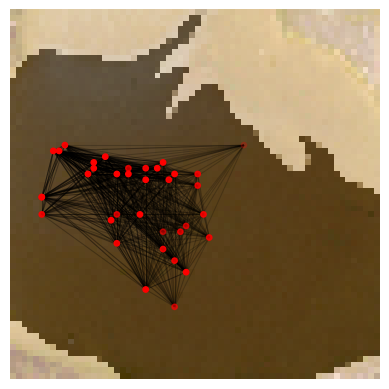

------------------------------
Processing 8561_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 554, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


100%|██████████| 554/554 [00:00<00:00, 1274.40it/s]


Filtered 12 spike trains by bursts. 34 remaining.
STTC matrix shape: (34, 34)
Optimized NetworkX graph constructed with 34 nodes and 498 edges.


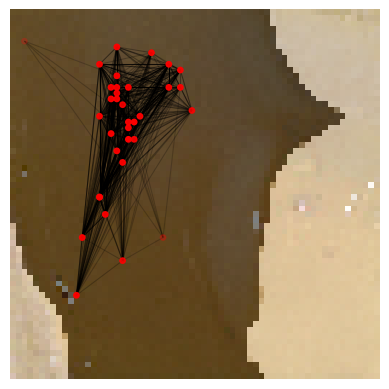

------------------------------
Processing 8562_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 107
Number of good clusters (Changed): 107
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 107
Number of good clusters (Changed): 107
-------------------------------------------------------


100%|██████████| 580/580 [00:00<00:00, 764.42it/s]


Filtered 8 spike trains by bursts. 39 remaining.
STTC matrix shape: (39, 39)
Optimized NetworkX graph constructed with 39 nodes and 726 edges.


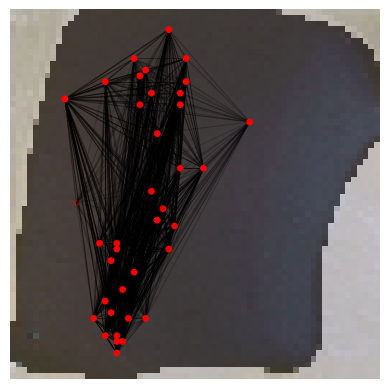

------------------------------
Processing 8562_7
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1077, disagreement: 21
Number of good clusters (Original): 401
Number of good clusters (Changed): 402
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1077, disagreement: 21
Number of good clusters (Original): 401
Number of good clusters (Changed): 402
-------------------------------------------------------


100%|██████████| 1098/1098 [00:01<00:00, 583.97it/s]


Filtered 21 spike trains by bursts. 236 remaining.
STTC matrix shape: (236, 236)
Optimized NetworkX graph constructed with 236 nodes and 22338 edges.


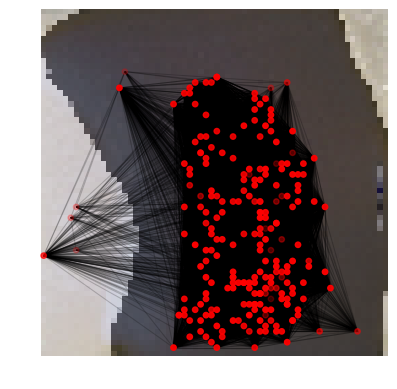

------------------------------
Processing 8602_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Number of good clusters (Original): 114
Number of good clusters (Changed): 114
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Number of good clusters (Original): 114
Number of good clusters (Changed): 114
-------------------------------------------------------


100%|██████████| 350/350 [00:00<00:00, 7482.69it/s]

Filtered 3 spike trains by bursts. 9 remaining.
STTC matrix shape: (9, 9)
Optimized NetworkX graph constructed with 9 nodes and 32 edges.


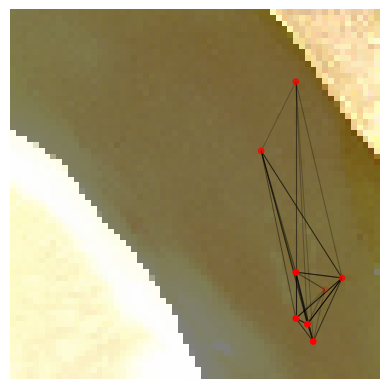

------------------------------
Processing 8602_2
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 456, disagreement: 0
Number of good clusters (Original): 132
Number of good clusters (Changed): 132
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 456, disagreement: 0
Number of good clusters (Original): 132
Number of good clusters (Changed): 132
-------------------------------------------------------


100%|██████████| 456/456 [00:00<00:00, 3377.58it/s]


Filtered 11 spike trains by bursts. 25 remaining.
STTC matrix shape: (25, 25)
Optimized NetworkX graph constructed with 25 nodes and 295 edges.


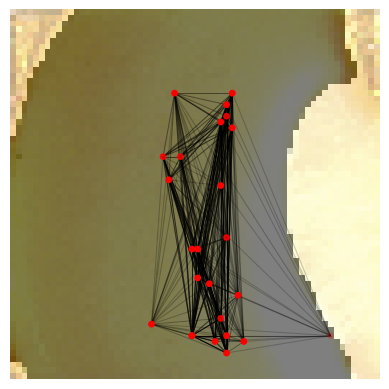

------------------------------
Processing 8602_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 438, disagreement: 0
Number of good clusters (Original): 117
Number of good clusters (Changed): 117
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 438, disagreement: 0
Number of good clusters (Original): 117
Number of good clusters (Changed): 117
-------------------------------------------------------


100%|██████████| 438/438 [00:00<00:00, 1255.58it/s]


Filtered 14 spike trains by bursts. 36 remaining.
STTC matrix shape: (36, 36)
Optimized NetworkX graph constructed with 36 nodes and 541 edges.


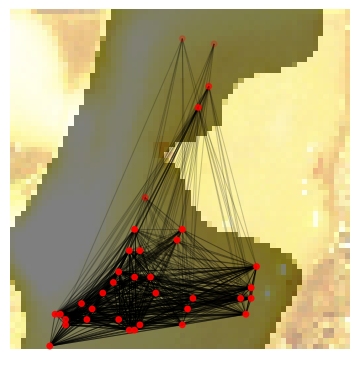

------------------------------
Processing 8602_6
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 375, disagreement: 0
Number of good clusters (Original): 128
Number of good clusters (Changed): 128
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 375, disagreement: 0
Number of good clusters (Original): 128
Number of good clusters (Changed): 128
-------------------------------------------------------


100%|██████████| 375/375 [00:00<00:00, 1702.89it/s]


Filtered 18 spike trains by bursts. 43 remaining.
STTC matrix shape: (43, 43)
Optimized NetworkX graph constructed with 43 nodes and 630 edges.


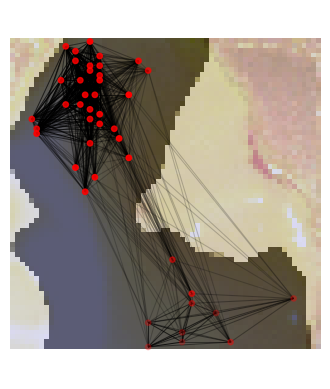

------------------------------
Processing 8603_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 653, disagreement: 0
Number of good clusters (Original): 187
Number of good clusters (Changed): 187
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 653, disagreement: 0
Number of good clusters (Original): 187
Number of good clusters (Changed): 187
-------------------------------------------------------


100%|██████████| 653/653 [00:00<00:00, 1059.18it/s]


Filtered 14 spike trains by bursts. 86 remaining.
STTC matrix shape: (86, 86)
Optimized NetworkX graph constructed with 86 nodes and 3646 edges.


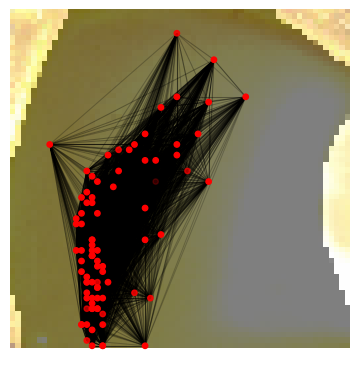

------------------------------
Processing 8603_2
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 386, disagreement: 0
Number of good clusters (Original): 118
Number of good clusters (Changed): 118
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 386, disagreement: 0
Number of good clusters (Original): 118
Number of good clusters (Changed): 118
-------------------------------------------------------


100%|██████████| 386/386 [00:00<00:00, 2711.99it/s]


Filtered 6 spike trains by bursts. 18 remaining.
STTC matrix shape: (18, 18)
Optimized NetworkX graph constructed with 18 nodes and 141 edges.


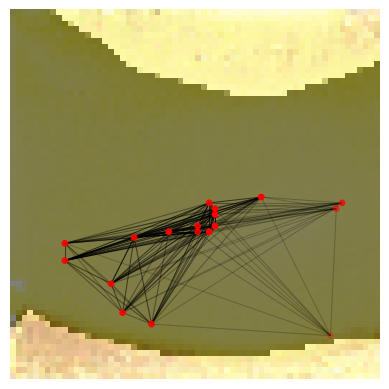

------------------------------
Processing 8604_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Number of good clusters (Original): 97
Number of good clusters (Changed): 97
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 350, disagreement: 0
Number of good clusters (Original): 97
Number of good clusters (Changed): 97
-------------------------------------------------------


100%|██████████| 350/350 [00:00<00:00, 3139.89it/s]


Filtered 8 spike trains by bursts. 23 remaining.
STTC matrix shape: (23, 23)
Optimized NetworkX graph constructed with 23 nodes and 239 edges.


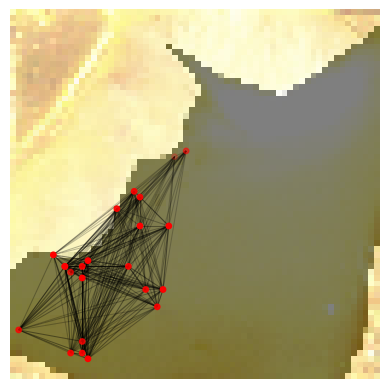

------------------------------
Processing 8604_2
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 331, disagreement: 0
Number of good clusters (Original): 117
Number of good clusters (Changed): 117
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 331, disagreement: 0
Number of good clusters (Original): 117
Number of good clusters (Changed): 117
-------------------------------------------------------


100%|██████████| 331/331 [00:00<00:00, 6249.78it/s]

Filtered 22 spike trains by bursts. 10 remaining.
STTC matrix shape: (10, 10)
Optimized NetworkX graph constructed with 10 nodes and 34 edges.


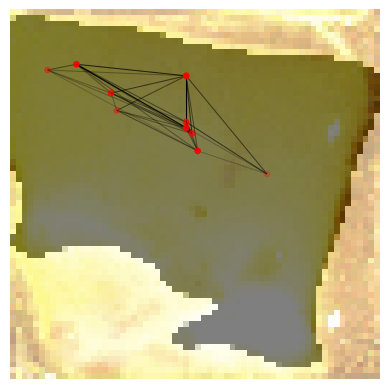

------------------------------
Processing 8604_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1330, disagreement: 0
Number of good clusters (Original): 470
Number of good clusters (Changed): 470
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 1330, disagreement: 0
Number of good clusters (Original): 470
Number of good clusters (Changed): 470
-------------------------------------------------------


100%|██████████| 1330/1330 [00:00<00:00, 1450.42it/s]


Filtered 64 spike trains by bursts. 43 remaining.
STTC matrix shape: (43, 43)
Optimized NetworkX graph constructed with 43 nodes and 788 edges.


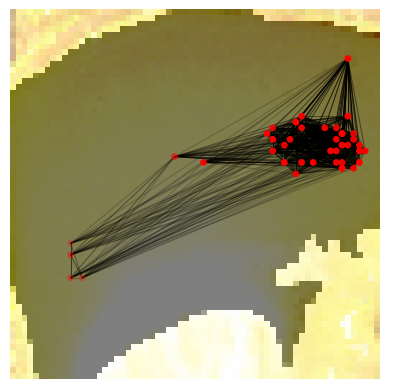

------------------------------
Processing 8604_6
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 406, disagreement: 0
Number of good clusters (Original): 136
Number of good clusters (Changed): 136
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 406, disagreement: 0
Number of good clusters (Original): 136
Number of good clusters (Changed): 136
-------------------------------------------------------


100%|██████████| 406/406 [00:00<00:00, 2969.73it/s]


Filtered 22 spike trains by bursts. 16 remaining.
STTC matrix shape: (16, 16)
Optimized NetworkX graph constructed with 16 nodes and 91 edges.


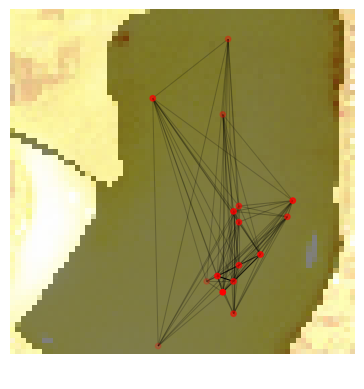

------------------------------
Processing 8605_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 540, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 540, disagreement: 0
Number of good clusters (Original): 119
Number of good clusters (Changed): 119
-------------------------------------------------------


100%|██████████| 540/540 [00:00<00:00, 1404.24it/s]


Filtered 4 spike trains by bursts. 43 remaining.
STTC matrix shape: (43, 43)
Optimized NetworkX graph constructed with 43 nodes and 893 edges.


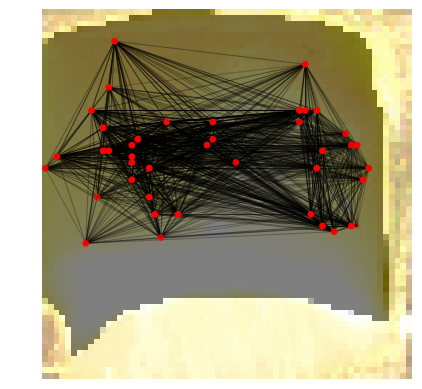

------------------------------
Processing 8605_2
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 393, disagreement: 0
Number of good clusters (Original): 73
Number of good clusters (Changed): 73
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 393, disagreement: 0
Number of good clusters (Original): 73
Number of good clusters (Changed): 73
-------------------------------------------------------


100%|██████████| 393/393 [00:00<00:00, 1386.78it/s]


Filtered 8 spike trains by bursts. 25 remaining.
STTC matrix shape: (25, 25)
Optimized NetworkX graph constructed with 25 nodes and 300 edges.


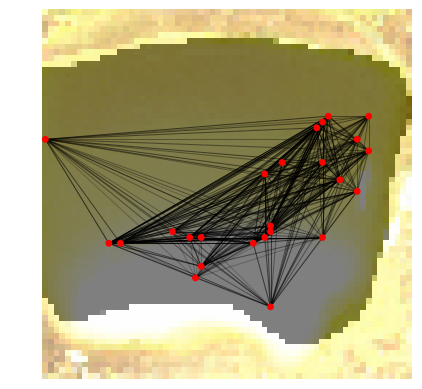

------------------------------
Processing 8605_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 644, disagreement: 0
Number of good clusters (Original): 176
Number of good clusters (Changed): 176
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 644, disagreement: 0
Number of good clusters (Original): 176
Number of good clusters (Changed): 176
-------------------------------------------------------


100%|██████████| 644/644 [00:00<00:00, 754.51it/s]


Filtered 7 spike trains by bursts. 104 remaining.
STTC matrix shape: (104, 104)
Optimized NetworkX graph constructed with 104 nodes and 5125 edges.


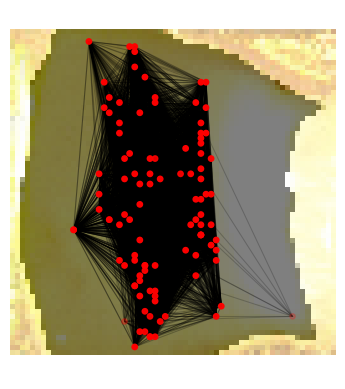

------------------------------
Processing 8605_6
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 146
Number of good clusters (Changed): 146
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 580, disagreement: 0
Number of good clusters (Original): 146
Number of good clusters (Changed): 146
-------------------------------------------------------


100%|██████████| 580/580 [00:00<00:00, 700.42it/s]


Filtered 10 spike trains by bursts. 75 remaining.
STTC matrix shape: (75, 75)
Optimized NetworkX graph constructed with 75 nodes and 2637 edges.


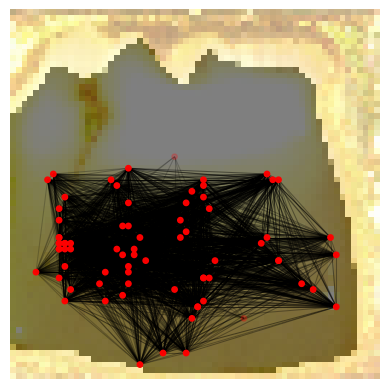

------------------------------
Processing 8606_1
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 357, disagreement: 0
Number of good clusters (Original): 75
Number of good clusters (Changed): 75
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 357, disagreement: 0
Number of good clusters (Original): 75
Number of good clusters (Changed): 75
-------------------------------------------------------


100%|██████████| 357/357 [00:00<00:00, 4694.06it/s]


Filtered 8 spike trains by bursts. 5 remaining.
STTC matrix shape: (5, 5)
Optimized NetworkX graph constructed with 5 nodes and 10 edges.


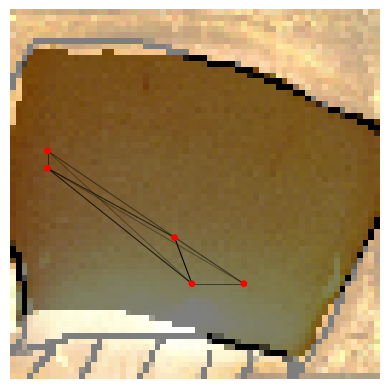

------------------------------
Processing 8606_2
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 558, disagreement: 0
Number of good clusters (Original): 181
Number of good clusters (Changed): 181
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 558, disagreement: 0
Number of good clusters (Original): 181
Number of good clusters (Changed): 181
-------------------------------------------------------


100%|██████████| 558/558 [00:00<00:00, 1263.36it/s]


Filtered 6 spike trains by bursts. 83 remaining.
STTC matrix shape: (83, 83)
Optimized NetworkX graph constructed with 83 nodes and 3306 edges.


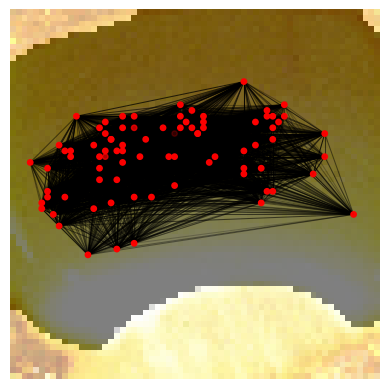

------------------------------
Processing 8606_5
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 450, disagreement: 0
Number of good clusters (Original): 91
Number of good clusters (Changed): 91
-------------------------------------------------------


100%|██████████| 450/450 [00:00<00:00, 736.73it/s]


Filtered 9 spike trains by bursts. 43 remaining.
STTC matrix shape: (43, 43)
Optimized NetworkX graph constructed with 43 nodes and 885 edges.


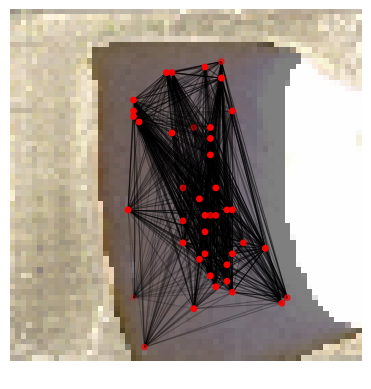

------------------------------
Processing 8606_6
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------
Comparison of Labels (Original vs. Changed)
KSLabel agreement: 323, disagreement: 0
Number of good clusters (Original): 55
Number of good clusters (Changed): 55
-------------------------------------------------------


100%|██████████| 323/323 [00:00<00:00, 1072.88it/s]


Filtered 4 spike trains by bursts. 21 remaining.
STTC matrix shape: (21, 21)
Optimized NetworkX graph constructed with 21 nodes and 205 edges.


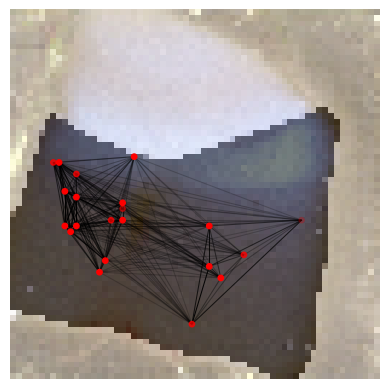

In [ ]:
# construct the obeserved graphs
Graphs = {}
folder_name_too_few_comps = []
for i, row in tqdm(df_overview.iterrows(), total=len(df_overview)):
    print("-"*30)
    print(f"Processing {row['folder']}")
    st_df, st, clu, best_cha_st, vectorized_map =  mea.get_stdf(row["folder_path"])

    # identify single units
    st_df = st_df[st_df["mua_labels"]=="good"]
    st_df = st_df[st_df["num_spikes"]>600]
    st_df = filter_by_bursts(st_df, row)
    st_df.reset_index(inplace=True, drop=True)

    # get coordinates of each spike sorted cluster
    st_df["x_coords"], st_df["y_coords"] = mea.chans_to_coords(st_df["chan_best"])

    # chage st to s
    st = st/SAMPLING_RATE

    sttc_matrix = np.load(row["slcc_path"])
    print(f"STTC matrix shape: {sttc_matrix.shape}")
    #assert np.all(sttc_matrix[sttc_matrix!=0]>0.3)#we are not interested in weak connections!
    sttc_matrix[sttc_matrix <= 0] = 0 #we are not interested in anticorr connections!
    assert sttc_matrix.shape[0] == st_df["clu"].nunique(), "STTC matrix rows do not match number of clusters in st_df."
    assert ~np.any(sttc_matrix>1), "This is extreamly unlikely. Check the sttc matrix"
    assert sttc_matrix.shape[0] == st_df["clu"].nunique(), "STTC matrix rows do not match number of clusters in st_df."

    G = graphs.construct_graph(st_df, sttc_matrix)
    isolated_nodes = [node for node, degree in dict(G.degree()).items() if degree == 0]
    assert len(isolated_nodes) == 0, f"Graph has isolated nodes: {isolated_nodes}"
    num_comps = graphs.get_n_relevant_components(G=G, minimum_size=2)
    if num_comps == 0:
        print(f"Graph has no relevant components")
        folder_name_too_few_comps.append(row["folder"])
        continue
    Graphs[row["folder"]] = G

    debug_graph_plotting(G, row) # uncomment to plot the graph
    # the edges of the graph have the attributes weight = sttc and pseudo_distance = 1-sttc

# Compare graphs directly

In [10]:
global_efficiencies = {}
average_clusterings = {}
average_node_strengths = {}
modularity_scores = {}
for i, row in tqdm(df_overview.iterrows(), total=len(df_overview)):
    if row["folder"] not in Graphs:
        continue
    G = Graphs[row["folder"]]
    global_efficiency = graphs.compute_global_efficiency_wrapper(G)
    average_clustering = graphs.average_clustering_wrapper(G)
    average_node_strength = graphs.average_node_strength_wrapper(G)
    modularity_score = graphs.modularity_wrapper(G)

    modularity_scores[row["folder"]] = modularity_score
    global_efficiencies[row["folder"]] = global_efficiency
    average_clusterings[row["folder"]] = average_clustering
    average_node_strengths[row["folder"]] = average_node_strength
df_overview["global_efficiency"] = df_overview["folder"].map(global_efficiencies)
df_overview["average_clustering"] = df_overview["folder"].map(average_clusterings)
df_overview["average_node_strength"] = df_overview["folder"].map(average_node_strengths)
df_overview["modularity_score"] = df_overview["folder"].map(modularity_scores)

  0%|          | 0/22 [00:00<?, ?it/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

...

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

Calculating global efficiency: 0source node [00:00, ?source node/s]

In [11]:
from scipy.stats import mannwhitneyu

In [12]:
mwu_global_efficiency = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["global_efficiency"].dropna(),
                          df_overview[df_overview["group"]=="Tumor"]["global_efficiency"].dropna())
print(f"Mann-Whitney U test for global efficiency: U={mwu_global_efficiency.statistic}, p-value={mwu_global_efficiency.pvalue}")

mwu_average_node_strength = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["average_node_strength"].dropna(),
                          df_overview[df_overview["group"]=="Tumor"]["average_node_strength"].dropna())
print(f"Mann-Whitney U test for average average_node_strength: U={mwu_average_node_strength.statistic}, p-value={mwu_average_node_strength.pvalue}")

mwu_average_clustering = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["average_clustering"].dropna(),
                          df_overview[df_overview["group"]=="Tumor"]["average_clustering"].dropna())
print(f"Mann-Whitney U test for average clustering: U={mwu_average_clustering.statistic}, p-value={mwu_average_clustering.pvalue}")

mwu_modularity_score = mannwhitneyu(df_overview[df_overview["group"]=="Sham"]["modularity_score"].dropna(),
                          df_overview[df_overview["group"]=="Tumor"]["modularity_score"].dropna())
print(f"Mann-Whitney U test for modularity score: U={mwu_modularity_score.statistic}, p-value={mwu_modularity_score.pvalue}")

Mann-Whitney U test for global efficiency: U=95.0, p-value=0.022914171535340932
Mann-Whitney U test for average average_node_strength: U=91.0, p-value=0.04431379228316605
Mann-Whitney U test for average clustering: U=65.0, p-value=0.7666793603687381
Mann-Whitney U test for modularity score: U=66.0, p-value=0.7168594361961285


In [13]:
def sig_bar(ax : plt.Axes, col_name : str, group_col_name : str, df : pd.DataFrame):
    
    sham = df[df[group_col_name]=="Sham"][col_name].dropna()
    tumor = df[df[group_col_name]=="Tumor"][col_name].dropna()
    mwu = mannwhitneyu(sham, tumor)
    print(f"Mann-Whitney U test for {col_name}: U={mwu.statistic}, p-value={mwu.pvalue}")

    y_range_org = (ax.get_ylim()[1] - ax.get_ylim()[0])
    print(y_range_org)

    x1 = 0
    x2 = 1
    y1 = ax.get_ylim()[1] + y_range_org * 0.05
    y2 = ax.get_ylim()[1] + y_range_org * 0.065

    if mwu.pvalue < 0.05:
        ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], color='black', lw=1)
        if mwu.pvalue > 0.01:
            ax.text((x1 + x2) / 2, y2, "*", ha='center', va='bottom', color='black')
        elif mwu.pvalue > 0.001:
            ax.text((x1 + x2) / 2, y2, "**", ha='center', va='bottom', color='black')
        else:
            ax.text((x1 + x2) / 2, y2, "***", ha='center', va='bottom', color='black')

    ylim_lower_new = ax.get_ylim()[0] 
    ylim_upper_new = y2 + y_range_org * 0.15
    ax.set_ylim(ylim_lower_new, ylim_upper_new)

In [14]:
df_overview = df_overview.sort_values(by="group", ascending=True)
df_overview

df_overview.to_excel(GRAPH_METRICS_PATH, index=False)

In [15]:
df_velocity = pd.read_excel("data/velocity_data.xlsx")
df_velocity

,Unnamed: 0,folder,group,velocity
0,0,8561_3,Tumor,8.126701
1,1,8561_5,Tumor,8.641172
2,2,8562_5,Sham,9.235165
3,3,8562_7,Sham,6.255156
4,4,8602_1,Tumor,6.850860
5,5,8602_2,Tumor,12.808116
6,6,8602_5,Tumor,8.368814
7,7,8602_6,Tumor,12.224617
8,8,8603_1,Tumor,4.188459
9,9,8603_2,Tumor,6.095984


In [16]:
df_overview = pd.merge(df_overview, 
                       df_velocity, 
                       left_on="folder",
                       right_on="folder", 
                       how="left",
                       suffixes=('', '_y'))
df_overview

,folder,folder_path,bin_path_x,analyzed,sle_path,sles_saved,image_path,mask_path,animal_number,slice_number,...,slcc_path,slcc_path_SLES,sttc_path_no_SLE,global_efficiency,average_clustering,average_node_strength,modularity_score,Unnamed: 0,group_y,velocity
0,8606_6,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8606,6,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.137366,0.186118,2.217343,1.954519e-01,21,Sham,10.922147
1,8606_2,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8606,2,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.168116,0.199619,11.299825,5.454927e-02,19,Sham,10.373092
2,8562_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,5,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.188207,0.244167,5.626489,5.653013e-02,2,Sham,9.235165
3,8562_7,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8562,7,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.080322,0.159289,28.201682,1.004490e-01,3,Sham,6.255156
4,8606_1,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8606,1,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.104196,0.306655,0.357180,0.000000e+00,18,Sham,21.706559
5,8605_6,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8605,6,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.120005,0.164211,8.595738,4.963998e-02,17,Sham,11.291391
6,8605_5,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8605,5,...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,1.153267,0.196627,13.682102,5.426280e-02,16,Sham,8.916819
7,8605_2,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,True,/media/ferdinand-forberger/Seagate Portable Dr...,/media/ferdinand-forberger/Seagate Portable Dr...,8605,2,...,/media/ferdinand-forberger/Seagate Portable Dr..

------------------------------
Current letter: A, column: global_efficiency
Global efficiency
Sham median 1.15, Glioma median 1.06, Fold difference 0.92
Mann-Whitney U test for global_efficiency: U=95.0, p-value=0.022914171535340932
0.4292648310925431
------------------------------
Current letter: B, column: average_node_strength
Average node strength
Sham median 5.45, Glioma median 2.61, Fold difference 0.48
Mann-Whitney U test for average_node_strength: U=91.0, p-value=0.04431379228316605
35.14427794585692
------------------------------
Current letter: C, column: average_clustering
Average clustering
Sham median 0.20, Glioma median 0.20, Fold difference 1.03
Mann-Whitney U test for average_clustering: U=65.0, p-value=0.7666793603687381
0.350051429522559
------------------------------
Current letter: D, column: modularity_score
Modularity score
Sham median 0.05, Glioma median 0.05, Fold difference 0.93
Mann-Whitney U test for modularity_score: U=66.0, p-value=0.7168594361961285
0.2443

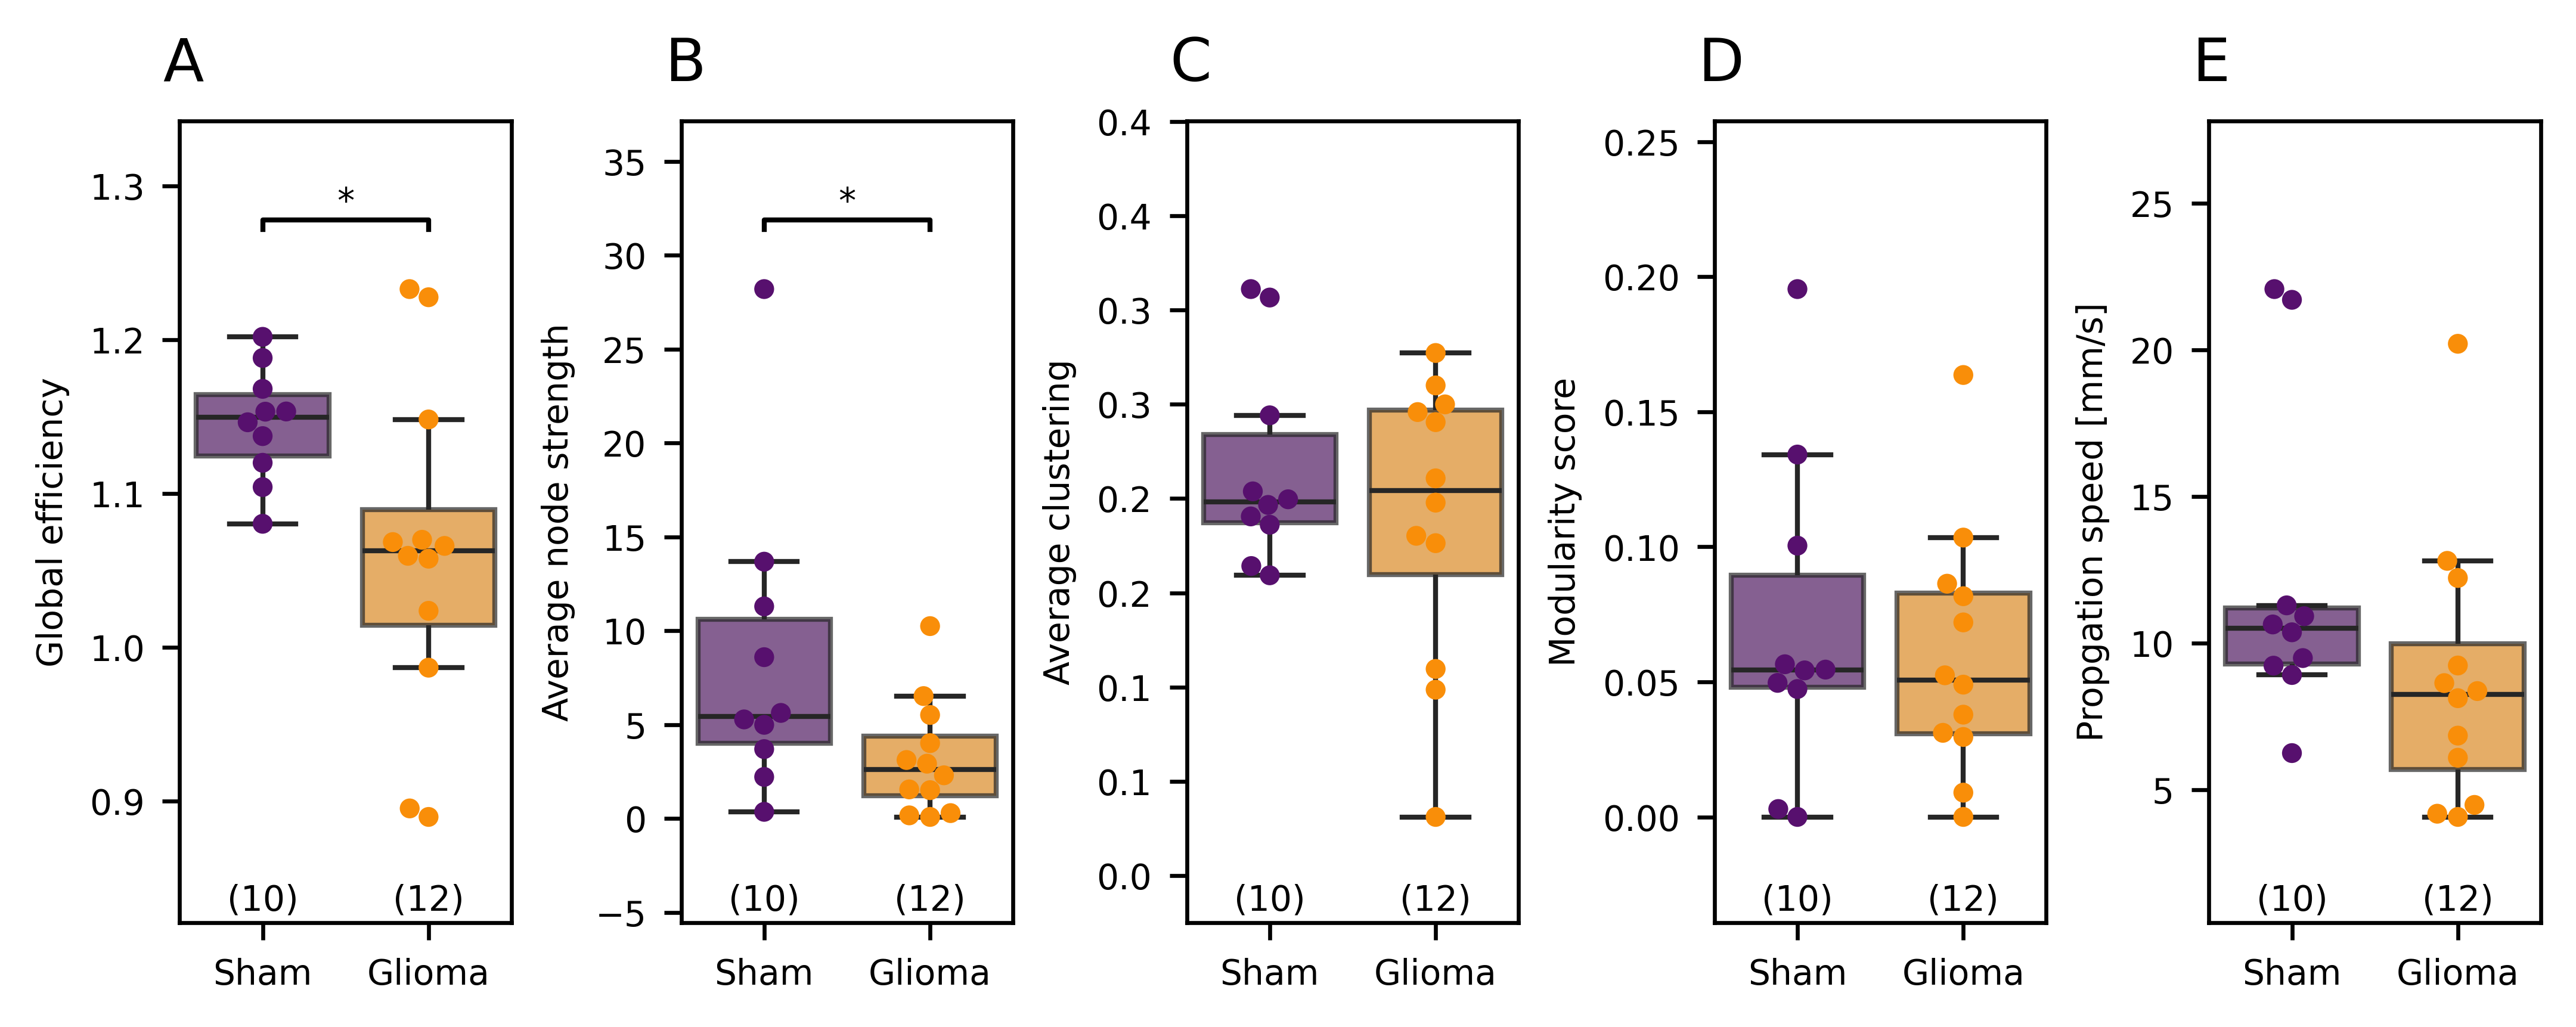

In [ ]:
from data_analysis.plotting import get_c_map_colors
colors = get_c_map_colors()

letters = ["A", "B", "C","D", "E"]

y_labels = ["Global efficiency", "Average node strength", "Average clustering", "Modularity score", "Propgation speed [mm/s]"]

all_metrics = ["global_efficiency", "average_node_strength", "average_clustering", "modularity_score", "velocity"]

x_ticks = ["Sham", "Glioma"]

cm= 1/2.54
plt.rcParams.update({'font.size': 7})
fig, ax = plt.subplots(1,5, figsize=(18*cm,7*cm, ), layout ="constrained",dpi=600)
ax= ax.flatten()

for i, column in enumerate(all_metrics):
    if i>4:
        break

    print("-"*30)
    print(f"Current letter: {letters[i]}, column: {column}")
    print(f"{y_labels[i]}")

    x1 = df_overview[df_overview["group"]=="Sham"][column].dropna()
    x2 = df_overview[df_overview["group"]=="Tumor"][column].dropna()
    print(f"Sham median {np.median(x1):.2f}, Glioma median {np.median(x2):.2f}, Fold difference {np.median(x2)/np.median(x1):.2f}")

    n_1 = len(x1)
    n_2 = len(x2)

    current_ax = ax[i]
    
    sns.swarmplot(x="group", y=column, data=df_overview, hue="group",ax=current_ax, palette=[colors[1],colors[3]], dodge=False,s=4)
    sns.boxplot(x="group", y=column, data=df_overview, ax=current_ax, 
                palette=[colors[1],colors[3]], hue="group", #width=0.4, 
                fliersize=0, zorder=0, boxprops={'alpha': 0.7})

    y_range = np.max(df_overview[column].dropna()) - np.min(df_overview[column].dropna())
    current_ax.set_ylim(np.min(df_overview[column].dropna()) - 0.2*y_range, None)
    y_level = current_ax.get_ylim()[0] + 0.01*y_range

    if True:#"3" in letters[i]:
        current_ax.text(0, y_level, f"({n_1})", ha='center', va='bottom')
        current_ax.text(1, y_level, f"({n_2})", ha='center', va='bottom')

    sig_bar(current_ax, column, "group", df_overview)
    current_ax.set_xticks([0, 1])
    current_ax.set_xticklabels(x_ticks)
    current_ax.set_xlabel("")
    current_ax.set_ylabel(y_labels[i])
    current_ax.set_xlim(-0.5, 1.5)

    if i in [0,2]:
        formatter = mticker.FormatStrFormatter('%.1f')
        current_ax.yaxis.set_major_formatter(formatter)
        
    current_ax.text(-0.05, 1.05, letters[i], transform=current_ax.transAxes,color="black", fontsize=12)

plt.savefig("plots/Figure_boxplots.png", dpi=600)
plt.show()